In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel('SementesAbobora.xlsx')

In [ ]:
df.head()

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,(A) Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,(A) Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,(A) Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,(A) Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,(A) Çerçevelik


In [ ]:
df.shape

(2500, 13)

Observe que essa base de dados possui os dados de classes de forma ordenada, isso pode ser um problema para o aprendizado de maquina. vamos começar a embaralhar os dados com o comando shuffle

In [ ]:
from sklearn.utils import shuffle

df = shuffle(df)

In [ ]:
df.head()

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
823,63474,958.930,366.5470,221.1802,64122,284.2844,0.7974,0.9899,0.7014,0.8674,1.6572,0.7756,(A) Çerçevelik
2251,73944,1106.772,460.6736,204.9183,74709,306.8362,0.8956,0.9898,0.7180,0.7586,2.2481,0.6661,(B) Ürgüp Sivrisi
656,72109,1031.801,414.9175,221.8285,72725,303.0050,0.8451,0.9915,0.6819,0.8512,1.8704,0.7303,(A) Çerçevelik
671,75716,1064.630,427.7998,225.9345,76238,310.4909,0.8492,0.9932,0.7441,0.8395,1.8935,0.7258,(A) Çerçevelik
2222,74941,1034.963,388.8436,246.4869,75646,308.8978,0.7734,0.9907,0.7344,0.8792,1.5775,0.7944,(B) Ürgüp Sivrisi


Agora temos os dados embaralhados. proximo passo: vamos conhecer o equilibrio das nossas classes (ja que temos um problema de classificaçao a ser resolvido)

In [ ]:
df['Class'].value_counts()

,count
Class,
(A) Çerçevelik,1300
(B) Ürgüp Sivrisi,1200


A base está equilibrada. caso nao estivesse, teriamos que aplicar tecnicas de reamostragem de dados ou até mesmo coletar mais dados para a  criaçao de nossa rede neural

analise exploratoria:

In [ ]:
#visualizaçao
import seaborn as sns
import matplotlib.pyplot as plt

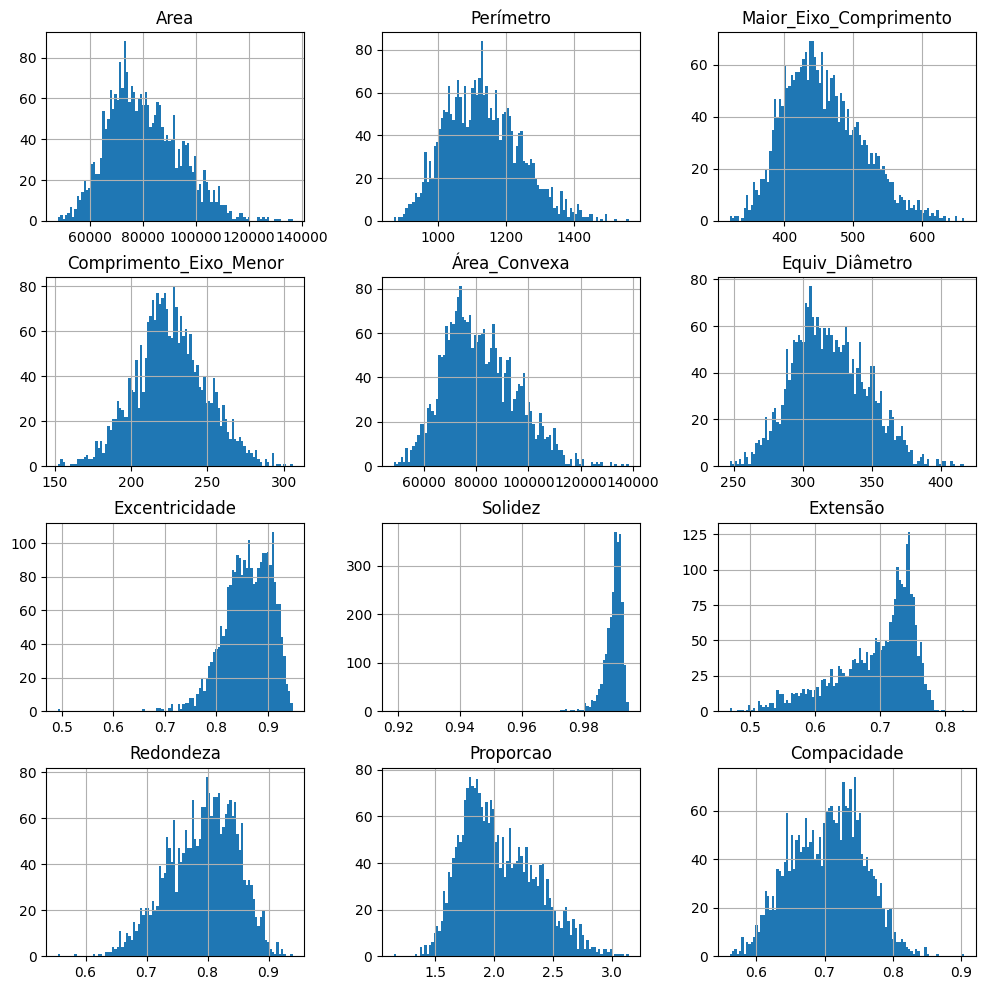

In [ ]:
#plotando histogramas para analisar a simetria dos dados
df.hist(bins=100, figsize=(12,12))
plt.show()

Podemos observar que existem muitas variaveis com a distribuiçao quase que normal, ou seja, nao temos muitos outliers exceto para as variaveis: proporcao, redondeza e compacidade, que possuem distribuicao assimetrica muito forte.

analise de correlacao:

<Axes: >

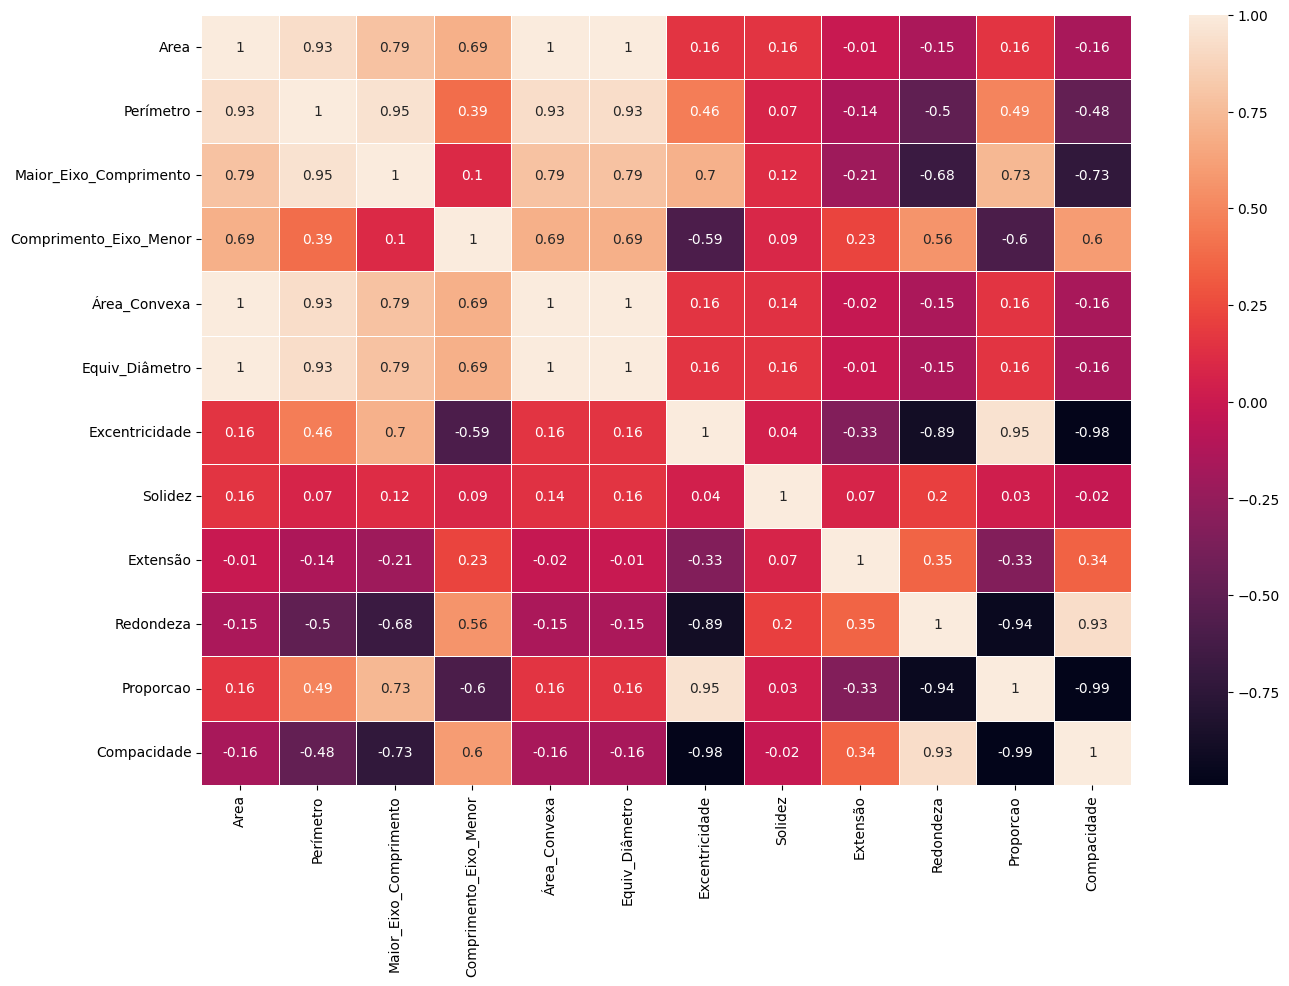

In [ ]:
correlation_matrix = df.drop('Class', axis=1).corr().round(2)

fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

#Tratando a variavel target

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 823 to 2205
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    2500 non-null   int64  
 1   Perímetro               2500 non-null   float64
 2   Maior_Eixo_Comprimento  2500 non-null   float64
 3   Comprimento_Eixo_Menor  2500 non-null   float64
 4   Área_Convexa            2500 non-null   int64  
 5   Equiv_Diâmetro          2500 non-null   float64
 6   Excentricidade          2500 non-null   float64
 7   Solidez                 2500 non-null   float64
 8   Extensão                2500 non-null   float64
 9   Redondeza               2500 non-null   float64
 10  Proporcao               2500 non-null   float64
 11  Compacidade             2500 non-null   float64
 12  Class                   2500 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 273.4 KB


In [ ]:
#utilizando label encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.Class = le.fit_transform(df['Class'])

In [ ]:
set(df['Class'])

{0, 1}

#Separando os dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 823 to 2205
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    2500 non-null   int64  
 1   Perímetro               2500 non-null   float64
 2   Maior_Eixo_Comprimento  2500 non-null   float64
 3   Comprimento_Eixo_Menor  2500 non-null   float64
 4   Área_Convexa            2500 non-null   int64  
 5   Equiv_Diâmetro          2500 non-null   float64
 6   Excentricidade          2500 non-null   float64
 7   Solidez                 2500 non-null   float64
 8   Extensão                2500 non-null   float64
 9   Redondeza               2500 non-null   float64
 10  Proporcao               2500 non-null   float64
 11  Compacidade             2500 non-null   float64
 12  Class                   2500 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 273.4 KB


In [ ]:
x = df[['Area', 'Perímetro', 'Comprimento_Eixo_Menor', 'Excentricidade', 'Solidez', 'Extensão', 'Redondeza', 'Proporcao', 'Compacidade']]
y = df['Class']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)
scaler.fit(x_test)

StandardScaler()

In [ ]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train.shape

(2000, 9)

In [ ]:
x_test.shape

(500, 9)

#Moldando nossas variaveis resposta

In [ ]:
type(y_train)

pandas.core.series.Series

In [ ]:
import numpy as np

#reshape() molda uma matriz sem alterar os dados da matriz
y_train = np.asarray(y_train).astype('float32').reshape((-1,1))
y_test = np.asarray(y_test).astype('float32').reshape((-1,1))

In [ ]:
type(y_train)

numpy.ndarray

In [ ]:
y_train.shape

(2000, 1)

#Construindo a arquitetura da rede neural multicamadas

utilizando tensorflow e keras, vamos construir a arquitetura da nossa primeira rede neural

In [ ]:
import tensorflow as tf

#keras libraries
from tensorflow import keras
from keras import models
from keras import layers
from keras import metrics
from keras.optimizers import Adam
from keras.metrics import Precision
from tqdm.keras import TqdmCallback

In [ ]:
#semente aleatorio para manter os mesmos dados
tf.random.set_seed(7)

#definindo entradas da rede + tamanho da batch de processamento
input_shape = x_train.shape[1]   #variaveis de entrada
output_shape = y_train.shape[1]  #classe preditora
batch_size = 20

#abrindo uma sequencia de neuronios
model = models.Sequential()

#input layer
#entrada de rede
model.add(layers.Dense(
    batch_size
    ,input_shape=(input_shape,)
    ,activation='relu'))  #relu é funcao de ativacao (a mais usada)

#hidden layer
#camada oculta
model.add(layers.Dense(
    12
    ,activation='relu'))

#hidden layer
#camada oculta
model.add(layers.Dense(
    6
    ,activation='relu'))

#dropout layer
#aplicando regularizacao
model.add(layers.Dropout(0.5))

#outout layer
#camada de saida
model.add(layers.Dense(
    output_shape
    ,activation='sigmoid'))

#configurar o otimzador Adam com uma learning rate especifica
#defina a learning rate desejada
learning_rate = 0.001
otimizador = Adam(learning_rate=learning_rate)

#compilar o modelo com o otimizador configurado
model.compile(loss='binary_crossentropy', optimizer=otimizador, metrics=['accuracy'])

#summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 537 (2.10 KB)

 Trainable params: 537 (2.10 KB)

 Non-trainable params: 0 (0.00 B)

Agora vamos executar as epocas de processamento para a rede treinar e encontrar o menor erro:

In [ ]:
#configurando as epocas de processamento para a convergencia do erro da funcao de custo
epoch = 100

hist = model.fit(x_train
                 ,y_train
                 ,epochs = epoch
                 ,batch_size=batch_size
                 ,shuffle=True
                 ,validation_data=(x_test, y_test)
                 ,verbose=0
                 ,callbacks=[TqdmCallback(verbose=0)])

0epoch [00:00, ?epoch/s]

In [ ]:
acc = '{:.2%}'.format(hist.history['accuracy'][-1])
print(f"O modelo possui uma acuracia de {acc} com {epoch} apochs de processamento")

O modelo possui uma acuracia de 83.40% com 100 apochs de processamento


#Validando nosso modelo

vamos plotar dois graficos para acompanhar a performance do modelo pelas epocas de processamento

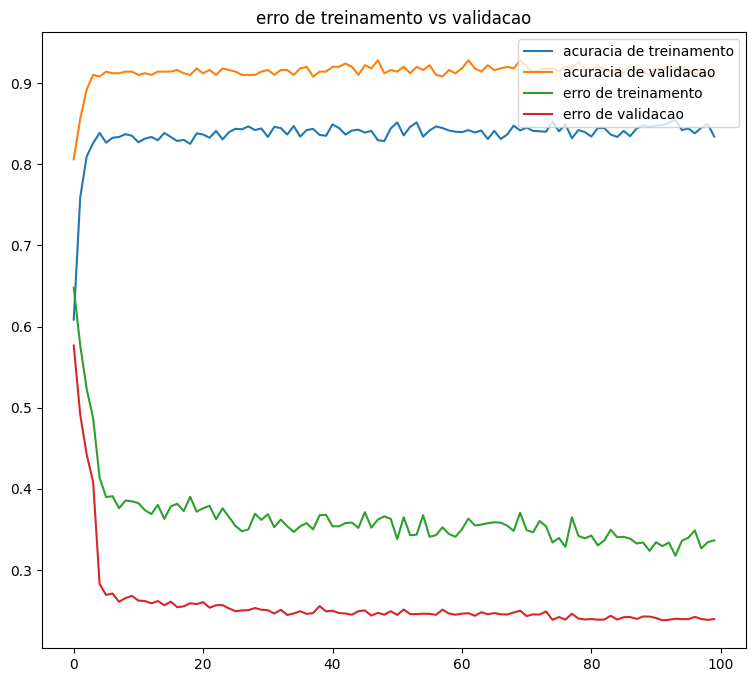

In [ ]:
#Visualizando os resultados de treino
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']

loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs_range = range(epoch)

#plot acuracia
plt.figure(figsize=(20, 8))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='acuracia de treinamento')
plt.plot(epochs_range, val_acc, label='acuracia de validacao')
plt.legend(loc='lower right')
plt.title('acuracia de treino e teste')

#plot erro de treinamento
plt.subplot(1,2,1)
plt.plot(epochs_range, loss, label='erro de treinamento')
plt.plot(epochs_range, val_loss, label='erro de validacao')
plt.legend(loc='upper right')
plt.title('erro de treinamento vs validacao')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

#predictions
y_pred = model.predict(x_test)
y_pred_class = [round(x(0)) for x in y_pred]
y_test_class = y_test

#classification report
class_names = []
for i in y.unique():
  class_names.append(le.inverse_transform([i])[0])

print(classification_report(y_test_class, y_pred_class, target_names=class_names))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


TypeError: 'numpy.ndarray' object is not callable